In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
ftypes = ['c1', 'c2', 'b1', 'b2']
methods = ['cs', '4p']
estimators = ['x', 'mu', 'var']

In [4]:
L = np.array([
    [2, 0],
    [-1, 2]
])
A = L @ L.T
x = np.array([1, -2])
b = A @ x
c = 20
y = x @ A @ x / 2 - b @ x + c
print(
    'A = {}'.format(A), '\n',
    'b = {}'.format(b), '\n',
    'c = {}'.format(c), '\n',
    'optimal solution = {}'.format(x), '\n',
    'optimal value = {}'.format(y)
)

def mu_fn(x, c=0): return x @ A @ x / 2 - b @ x + c

def sigmoid(y): return 1 / (1 + np.exp(-y))

A = [[ 4 -2]
 [-2  5]] 
 b = [  8 -12] 
 c = 20 
 optimal solution = [ 1 -2] 
 optimal value = 4.0


In [6]:
opts = {
    'x': x,
    'c1': {'mu': mu_fn(x, c=20), 'var': (1 + np.linalg.norm(x) * np.cos(np.pi * np.linalg.norm(x)))**2},
    'c2': {'mu': 20 * sigmoid(mu_fn(x)/800 - 2), 'var': (1 + np.linalg.norm(x) * np.cos(np.pi * np.linalg.norm(x)))**2},
    'b1': {'mu': mu_fn(x)/2000 + .3}, 
    'b2': {'mu':2 * sigmoid(mu_fn(x)/600 - 2)}
}
for i in [1,2]:
    key = 'b{}'.format(i)
    opts[key]['var'] = opts[key]['mu'] * (1- opts[key]['mu'])
print(opts)

{'x': array([ 1, -2]), 'c1': {'mu': 4.0, 'var': 7.016178183544153}, 'c2': {'mu': 2.3423798175156105, 'var': 7.016178183544153}, 'b1': {'mu': 0.292, 'var': 0.20673599999999998}, 'b2': {'mu': 0.23286280194167774, 'var': 0.1786377174135487}}


`csv`-reader

In [7]:
def csvPath(envs, ftype, method, estimator): return "../outputResults/d2{}#T#{}_{}_{}.csv".format(envs, ftype, method, estimator)

## statistical calculators
`get_norm_x` outputs the Euclidean distance between current point and optimal point.  
`get_centroid` outputs the centroid of all points over the sample paths.

In [72]:
# def get_norm_x(series, x=opts['x']):
#     s = list(map(lambda a: np.linalg.norm(np.array(a)-x), series.tolist()))
#     return pd.Series(s, index=series.index)

# def get_Centroid(array):
#     c = np.mean(list(map(lambda x: np.array(x), array.tolist())), axis=0)
#     return pd.Series(c)

def get_x_floats(s): return np.array(list(map(float, re.findall('(-?\d+.\d+)', s))))

def get_centroid(row):
    c = np.mean(row.apply(get_x_floats))
    return pd.Series(c)

def get_norm_x(row, x=opts['x']):
    s = row.apply(lambda a: np.linalg.norm(x - get_x_floats(a)))
    return pd.Series(s, index=row.index)

### simple test

In [9]:
dfs = {}
for method in methods:
    dfs[method] = {each: pd.read_csv(csvPath('Chp', 'b1', method, each)) for each in estimators}

In [78]:
dfs['cs']['x_se'] = dfs['cs']['x'].apply(get_norm_x, axis=1)

In [73]:
for key in methods:
    dfs[key]['mse_x'] = dfs[key]['x'].apply(get_norm_x, axis=1)
    dfs[key]['xCentroid'] = dfs[key]['x'].apply(get_centroid, axis=1)

KeyboardInterrupt: 

In [87]:
lines = {'cs': '-.', '4p': '--'}
colors = {'cs': 'lightskyblue', '4p': 'orange'}
labels = {'cs': 'constant', '4p': '4-points'}

def myPlots(df, line, color, label, xlog=True, CI=True, alpha=.95):
    n = df.shape[0]
    x = np.log10(1+np.arange(n)) if xlog else np.arange(n)
    m = df.mean(axis=1)
    plt.plot(x, m, linestyle=line, label=label)
    if CI:
        l = df.quantile((1 - alpha)/2, axis=1)
        u = df.quantile((1 + alpha)/2, axis=1)
        plt.fill_between(x, l, u, alpha=.3, color=color)

def plotEuclid(df, dpi=500, xlog=True, alpha=.95):
    plt.figure(dpi=dpi)
    for key in methods:
        myPlots(df[key]['x_se'], lines[key], colors[key], labels[key], xlog, alpha=alpha)
    plt.grid(True)
    plt.legend()
    plt.show()
    plt.close()

def plotCentroidPath(df, dpi=500):
    plt.figure(dpi=dpi)
    for key in methods:
        plt.plot(df[key]['centroid'][0], df[key]['centroid'][1], linestyle=lines[key], color=colors[key], label=labels[key])
    plt.grid(True)
    plt.legend()
    plt.show()
    plt.close()

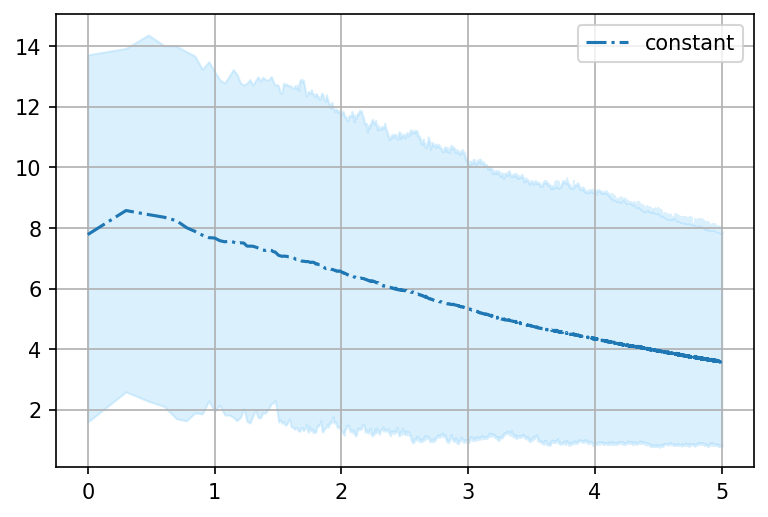

In [90]:
plt.figure(dpi=150)
myPlots(dfs['cs']['x_se'],'-.', 'lightskyblue', 'constant')
plt.grid(True)
plt.legend()
plt.show()
plt.close()

**plots**

`myPlots` simply takes the place of `plt.plot` for repeated codes...

In [ ]:
plt.figure(dpi=500)
mx = np.log10(1+np.arange(n))
for key in methods:
    m = dfs[key]['mse_x'].mean(axis=1)[1:]
    l = dfs[key]['mse_x'].quantile(.025, axis=1)[1:]
    u = dfs[key]['mse_x'].quantile(.975, axis=1)[1:]
    plt.plot(mx, m, label=key)
    plt.fill_between(mx, l, u, alpha=.3)
plt.grid(True)
plt.legend()
plt.show()
plt.close()

In [ ]:
dfs['cs']